In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 6,                # reduced for small figure
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.6,
    "legend.fontsize": 5.5,
    "legend.title_fontsize": 5.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,            # ensures editable text in Illustrator
    "ps.fonttype": 42
})

def make_fixed_axis(axis_size=1.25, label_space=0.15):
    """Create figure with a fixed physical data-area size."""
    figsize = (axis_size + label_space, axis_size + label_space)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_box_aspect(1)  # ensures square data region
    return fig, ax

Sampling 17095 paired points per strain


C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\distributions.py:1185: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', T

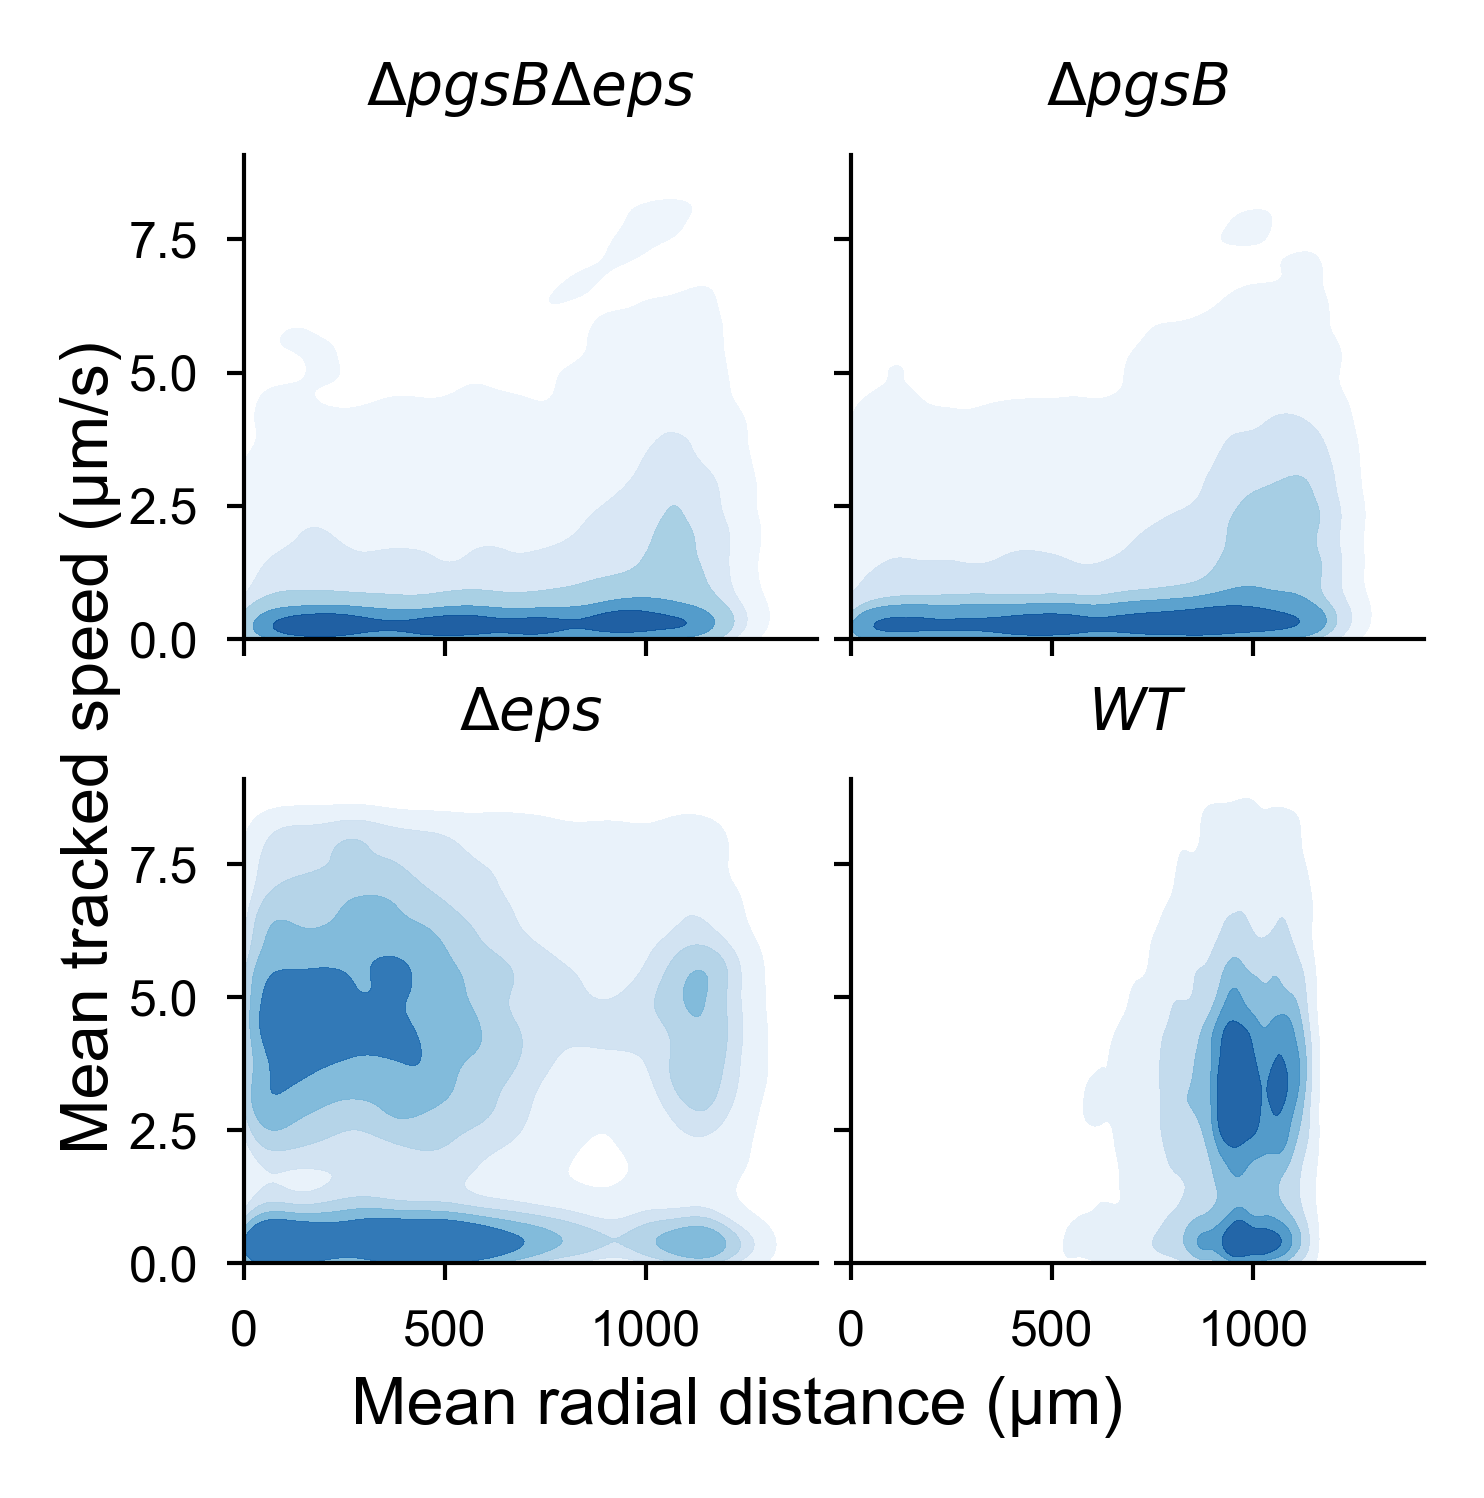

In [5]:
#extracting and plotting data for particle trajectories at t=10 hours
WT_mean_speed_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\WT mean speed.txt")
WT_mean_X_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\WT mean X.txt")

DPGAEPS_mean_speed_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\DPGAEPS mean speed.txt")
DPGAEPS_mean_X_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\DPGAEPS mean X.txt")

DPGA_mean_speed_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\DPGA mean speed.txt")
DPGA_mean_X_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\DPGA mean X.txt")

DEPS_mean_speed_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\DEPS mean speed.txt")
DEPS_mean_X_10 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 11 hrs\Tracked text data\DEPS mean X.txt")


N_min = min(
    len(WT_mean_speed_10), len(DEPS_mean_speed_10),
    len(DPGA_mean_speed_10), len(DPGAEPS_mean_speed_10),
    len(WT_mean_X_10), len(DEPS_mean_X_10),
    len(DPGA_mean_X_10), len(DPGAEPS_mean_X_10)
)
print(f"Sampling {N_min} paired points per strain")

# Randomly sample *same indices* for X and speed (to stay paired)
rng = np.random.default_rng(42)

def paired_sample(x, y, n, rng):
    idx = rng.choice(len(x), n, replace=False)
    return np.array(x)[idx], np.array(y)[idx]

WT_X, WT_V = paired_sample(WT_mean_X_10, WT_mean_speed_10, N_min, rng)
DEPS_X, DEPS_V = paired_sample(DEPS_mean_X_10, DEPS_mean_speed_10, N_min, rng)
DPGA_X, DPGA_V = paired_sample(DPGA_mean_X_10, DPGA_mean_speed_10, N_min, rng)
DPGAEPS_X, DPGAEPS_V = paired_sample(DPGAEPS_mean_X_10, DPGAEPS_mean_speed_10, N_min, rng)


#plotting
data = {
    r"$\Delta pgsB \Delta eps$": (DPGAEPS_X, DPGAEPS_V),
    r"$\Delta pgsB$": (DPGA_X, DPGA_V),
    r"$\Delta eps$": (DEPS_X, DEPS_V),
    r"$WT$": (WT_X, WT_V)
}

colors = {
    r"$WT$": "#0072B2",
    r"$\Delta eps$": "#E69F00",
    r"$\Delta pgsB$": "#009E73",
    r"$\Delta pgsB \Delta eps$": "#D55E00"
}

cmap_bright = 'Blues'  
all_x = np.concatenate([v[0] for v in data.values()])
all_y = np.concatenate([v[1] for v in data.values()])
xmax = np.nanmax(all_x) * 1.05
ymax = np.nanmax(all_y) * 1.05

fig, axes = plt.subplots(2, 2, figsize=(2.35, 2.35), dpi=600,
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, (strain, (x, y)) in zip(axes, data.items()):
    sns.kdeplot(
        x=x, y=y,
        fill=True, thresh=0.05, levels=6,
        bw_adjust=0.7,
        alpha=0.9,  # A bit more solid so bright regions stand out
        cmap=cmap_bright,
        linewidths=0.4, 
        ax=ax
    )
    ax.set_facecolor('white')  # Ensures background stays white
    ax.set_title(strain, fontsize=7)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(width=0.5, length=2, labelsize=6)


fig.supxlabel("Mean radial distance (µm)", fontsize=8)
fig.supylabel("Mean tracked speed (µm/s)", fontsize=8)

plt.tight_layout(pad=0.35)
plt.show()


Sampling 5648 paired points per strain


C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\distributions.py:1185: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
C:\Users\ayantis\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', T

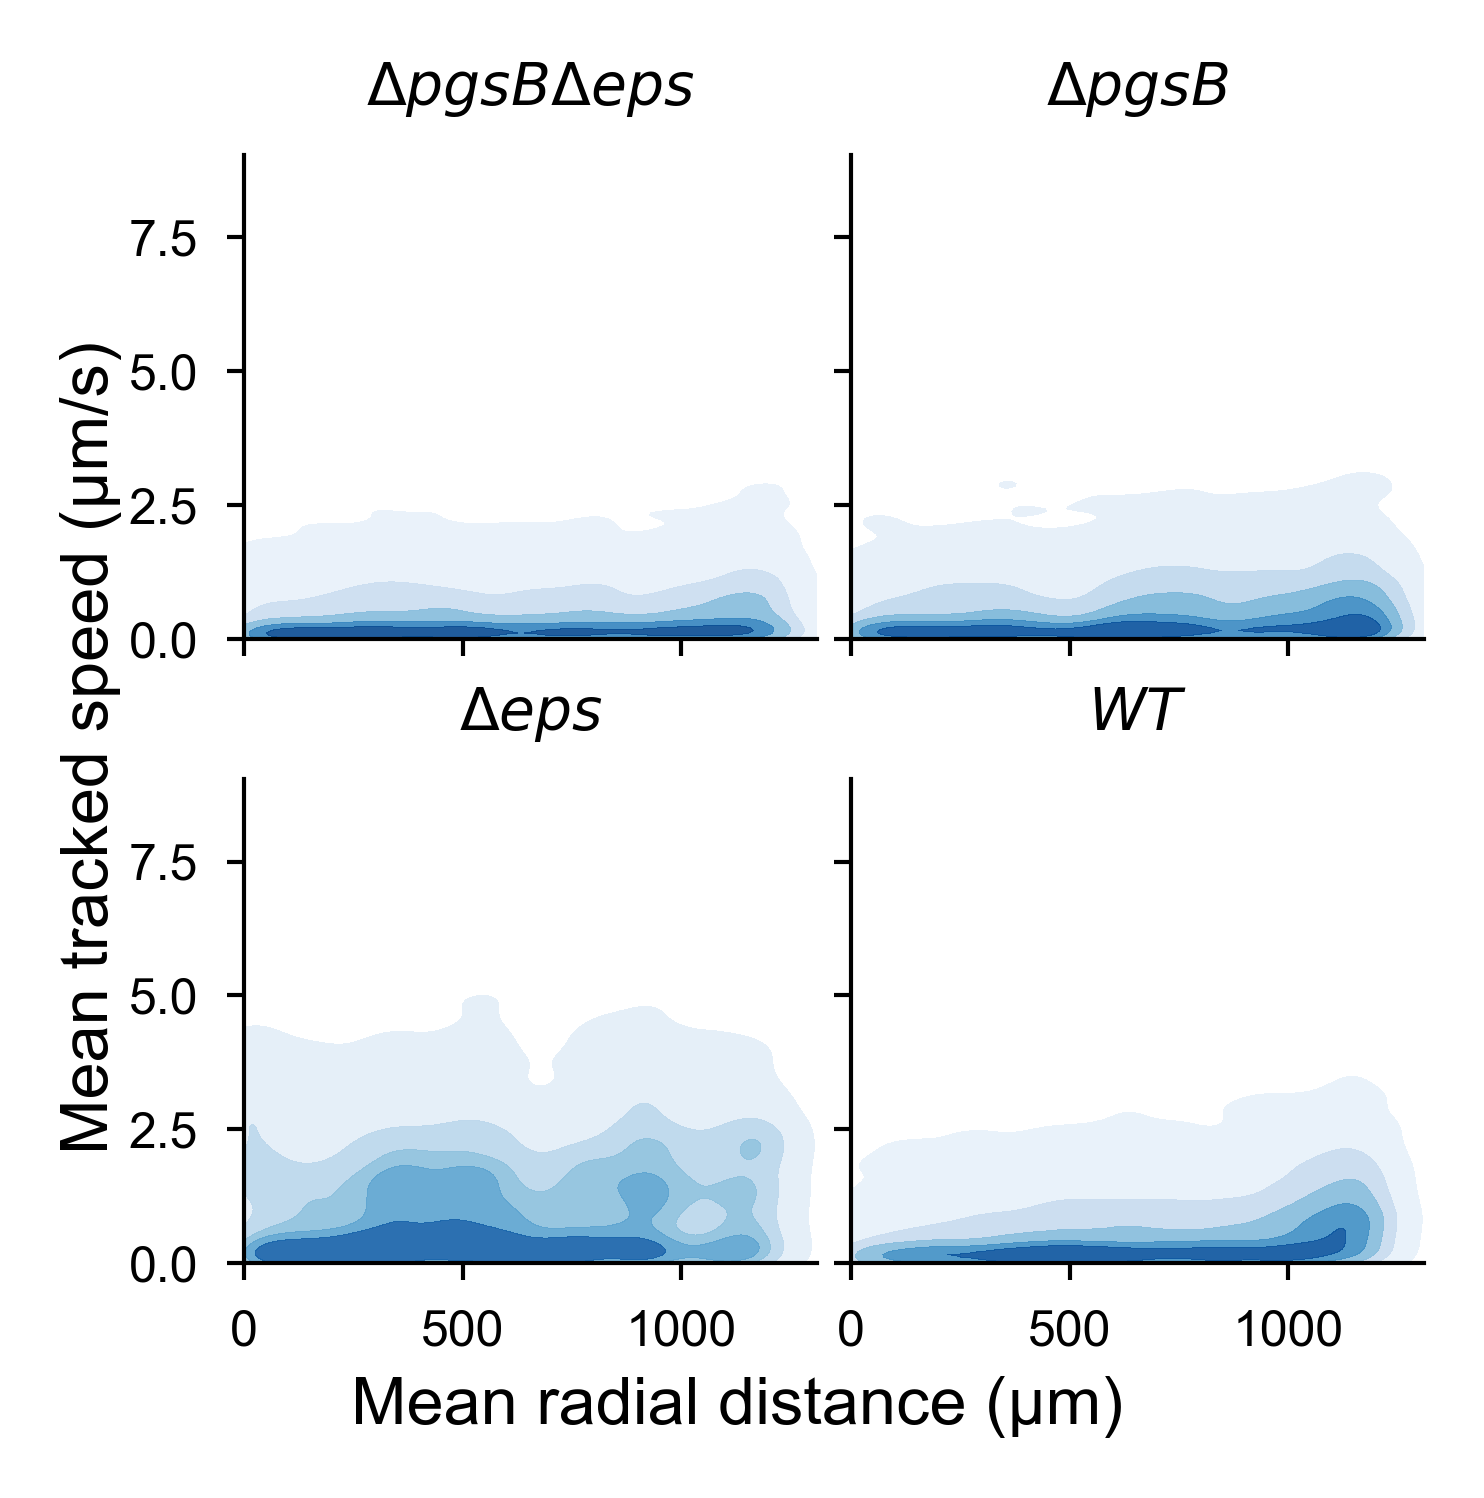

In [6]:
#extracting and plotting data for particle trajectories at t=0 hours
WT_mean_speed_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\WT mean speed.txt")
WT_mean_X_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\WT mean X.txt")

DPGAEPS_mean_speed_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\DPGAEPS mean speed.txt")
DPGAEPS_mean_X_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\DPGAEPS mean X.txt")

DPGA_mean_speed_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\DPGA mean speed.txt")
DPGA_mean_X_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\DPGA mean X.txt")

DEPS_mean_speed_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\DEPS mean speed.txt")
DEPS_mean_X_0 = np.loadtxt(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0802 Phase tracking at t = 0, 11 and 22 hrs\t = 0 hrs\Tracked text data\DEPS mean X.txt")

N_min = min(
    len(WT_mean_speed_0), len(DEPS_mean_speed_0),
    len(DPGA_mean_speed_0), len(DPGAEPS_mean_speed_0),
    len(WT_mean_X_0), len(DEPS_mean_X_0),
    len(DPGA_mean_X_0), len(DPGAEPS_mean_X_0)
)
print(f"Sampling {N_min} paired points per strain")

# Randomly sample *same indices* for X and speed (to stay paired)

rng = np.random.default_rng(42)
WT_X, WT_V = paired_sample(WT_mean_X_0, WT_mean_speed_0, N_min, rng)
DEPS_X, DEPS_V = paired_sample(DEPS_mean_X_0, DEPS_mean_speed_0, N_min, rng)
DPGA_X, DPGA_V = paired_sample(DPGA_mean_X_0, DPGA_mean_speed_0, N_min, rng)
DPGAEPS_X, DPGAEPS_V = paired_sample(DPGAEPS_mean_X_0, DPGAEPS_mean_speed_0, N_min, rng)


#plotting
data = {
    r"$\Delta pgsB \Delta eps$": (DPGAEPS_X, DPGAEPS_V),
    r"$\Delta pgsB$": (DPGA_X, DPGA_V),
    r"$\Delta eps$": (DEPS_X, DEPS_V),
    r"$WT$": (WT_X, WT_V)
}


cmap_bright = 'Blues'  
all_x = np.concatenate([v[0] for v in data.values()])
all_y = np.concatenate([v[1] for v in data.values()])
xmax = np.nanmax(all_x) * 1.05
ymax = np.nanmax(all_y) * 1.05

fig, axes = plt.subplots(2, 2, figsize=(2.35, 2.35), dpi=600,
                         sharex=True, sharey=True)
axes = axes.flatten()

for ax, (strain, (x, y)) in zip(axes, data.items()):
    sns.kdeplot(
        x=x, y=y,
        fill=True, thresh=0.05, levels=6,
        bw_adjust=0.7,
        alpha=0.9,  # A bit more solid so bright regions stand out
        cmap=cmap_bright,
        linewidths=0.4, 
        ax=ax
    )
    ax.set_facecolor('white')  # Ensures background stays white
    ax.set_title(strain, fontsize=7)
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(width=0.5, length=2, labelsize=6)

fig.supxlabel("Mean radial distance (µm)", fontsize=8)
fig.supylabel("Mean tracked speed (µm/s)", fontsize=8)

plt.tight_layout(pad=0.35)
plt.show()
